In [1]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm
from torchmetrics.functional import structural_similarity_index_measure



class MVTecLOCODataset(Dataset):
    def __init__(self, root_dir, split='train', anomaly_type='logical_anomalies', transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []  # 0 for normal, 1 for anomaly

        if split == 'train':
            # Load 'good' images for training
            good_dir = os.path.join(root_dir, 'train', 'good')
            self._load_images_from_folder(good_dir, label=0)
        elif split == 'test':
            # Load 'good' and specified anomalies for testing
            good_dir = os.path.join(root_dir, 'test', 'good')
            anomaly_dir = os.path.join(root_dir, 'test', anomaly_type)
            self._load_images_from_folder(good_dir, label=0)
            self._load_images_from_folder(anomaly_dir, label=1)
        else:
            raise ValueError(f"Invalid split: {split}")

    def _load_images_from_folder(self, folder, label):
        if not os.path.isdir(folder):
            print(f"Folder {folder} is missing!")
            return
        for root, _, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file)
                    self.image_paths.append(img_path)
                    self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label, img_path


In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size[0] // patch_size) * (img_size[1] // patch_size)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.position_embeddings = nn.Parameter(torch.zeros(1, self.n_patches, embed_dim))

    def forward(self, x):
        x = self.proj(x)  # Shape: (batch_size, embed_dim, n_patches_h, n_patches_w)
        x = x.flatten(2)  # Shape: (batch_size, embed_dim, n_patches)
        x = x.transpose(1, 2)  # Shape: (batch_size, n_patches, embed_dim)
        x = x + self.position_embeddings
        return x


In [3]:
class ViTEncoder(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim, depth, num_heads):
        super(ViTEncoder, self).__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.embed_dim = embed_dim
        self.n_patches = self.patch_embedding.n_patches
        self.fc_mu = nn.Linear(self.n_patches * embed_dim, embed_dim)
        self.fc_logvar = nn.Linear(self.n_patches * embed_dim, embed_dim)

    def forward(self, x):
        x = self.patch_embedding(x)  # (batch_size, n_patches, embed_dim)
        #x = x.transpose(0, 1)  # (n_patches, batch_size, embed_dim)
        x = self.transformer_encoder(x)  # (n_patches, batch_size, embed_dim)
        #x = x.transpose(0, 1)  # (batch_size, n_patches, embed_dim)
        x = x.flatten(1)  # (batch_size, n_patches * embed_dim)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


In [4]:
class ConvDecoder(nn.Module):
    def __init__(self, img_size, in_channels, embed_dim):
        super(ConvDecoder, self).__init__()
        self.img_size = img_size  # Store the target image size
        self.embed_dim = embed_dim
        self.init_size = (img_size[0] // 16, img_size[1] // 16)
        self.fc = nn.Linear(embed_dim, 512 * self.init_size[0] * self.init_size[1])
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, in_channels, kernel_size=4, stride=2, padding=1),
            #nn.Sigmoid()
            nn.Tanh()
        )

    def forward(self, z):
        batch_size = z.size(0)
        x = self.fc(z)
        x = x.view(batch_size, 512, self.init_size[0], self.init_size[1])
        x = self.decoder(x)
        # Resize to match the input image dimensions
        x = nn.functional.interpolate(x, size=self.img_size, mode='bilinear', align_corners=False)
        return x

In [5]:
class ViTVAE(nn.Module):
    def __init__(self, img_size=(1100, 1600), patch_size=64, in_channels=3, embed_dim=512, depth=6, num_heads=8):
        super(ViTVAE, self).__init__()
        self.encoder = ViTEncoder(img_size, patch_size, in_channels, embed_dim, depth, num_heads)
        self.decoder = ConvDecoder(img_size, in_channels, embed_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar


In [6]:
import numpy as np
from sklearn.metrics import roc_auc_score
#def evaluate(model, dataloader, criterion, device):
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    all_scores = []
    all_labels = []
    # Define KL weight
    kld_weight = 1e-4  # Start with a smaller value
    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            outputs, mu, logvar = model(images)
            #recon_loss = criterion(outputs, images)
            #recon_loss = recon_loss.view(recon_loss.size(0), -1).mean(dim=1)  # Per-image loss
            outputs_ssim = (outputs + 1) / 2
            images_ssim = (images + 1) / 2

            ssim_loss = 1 - structural_similarity_index_measure(outputs_ssim, images_ssim, data_range=1.0)            
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            #anomaly_scores = recon_loss + kld_loss * 1e-3  # Adjust weight as needed
            anomaly_scores = ssim_loss + kld_loss * kld_weight   # Adjust weight as needed
            all_scores.extend(anomaly_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            #total_loss += recon_loss.sum().item()
            total_loss += ssim_loss.sum().item()
    avg_loss = total_loss / len(dataloader.dataset)
    # Compute AUROC
    auroc = roc_auc_score(all_labels, all_scores)
    return avg_loss, auroc


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_reconstruction(model, dataloader, device):
    model.eval()
    images, labels, paths = next(iter(dataloader))
    images = images.to(device)
    with torch.no_grad():
        reconstructed, _, _ = model(images)
    images = images.cpu().numpy().transpose(0, 2, 3, 1)
    reconstructed = reconstructed.cpu().numpy().transpose(0, 2, 3, 1)

    # Rescale images from [-1, 1] to [0, 1]
    images = (images + 1) / 2.0
    reconstructed = (reconstructed + 1) / 2.0

    # Ensure the pixel values are clipped between 0 and 1
    images = np.clip(images, 0, 1)
    reconstructed = np.clip(reconstructed, 0, 1)

    # Determine the number of images to display
    num_images = min(len(images), 5)

    # Adjust the axes array to handle cases where num_images < 5
    fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))

    # If num_images is 1, axes may not be a 2D array; adjust accordingly
    if num_images == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    for i in range(num_images):
        axes[0, i].imshow(images[i])
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i])
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


In [8]:
#def train(model, dataloader, optimizer, criterion, device):
def train(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_recon_loss = 0.0
    running_kld_loss = 0.0

    # Define KL weight
    kld_weight = 1e-4  # Start with a smaller value

    # Create a progress bar using tqdm
    pbar = tqdm(dataloader, desc='Training', leave=False)
    
    for images, _, _ in pbar:
        images = images.to(device)
        optimizer.zero_grad()
        outputs, mu, logvar = model(images)
        
        #####################################################################
        #recon_loss = criterion(outputs, images).mean()
        #kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        #loss = recon_loss + kld_loss * 1e-3  # Adjusted KL divergence weight
        ######################################################################
        outputs_ssim = (outputs + 1) / 2
        images_ssim = (images + 1) / 2
        
        ssim_loss = 1 - structural_similarity_index_measure(outputs_ssim, images_ssim, data_range=1.0)
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = ssim_loss + kld_loss * kld_weight  # Adjust KLD weight if necessary

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        #running_recon_loss += recon_loss.item()
        running_recon_loss += ssim_loss.item()
        running_kld_loss += kld_loss.item()

        # Update progress bar with the current loss values
        pbar.set_postfix({
            'Loss': f'{loss.item():.6f}',
            #'Recon Loss': f'{recon_loss.item():.6f}',
            'Recon Loss': f'{ssim_loss.item():.6f}',
            'KL Loss': f'{kld_loss.item():.6f}'
        })

    avg_loss = running_loss / len(dataloader)
    avg_recon_loss = running_recon_loss / len(dataloader)
    avg_kld_loss = running_kld_loss / len(dataloader)
    return avg_loss, avg_recon_loss, avg_kld_loss

Loading checkpoint from '/home/hafiz/my_thesis/seg_recons/VitVae2_checkpoint_epoch_520.pth'


/tmp/ipykernel_554398/3332151776.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Resuming training from epoch 520.


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 521/1020, Train Loss: 0.083062, Recon Loss: 0.080627, KL Loss: 2.434778, Test Loss: 0.052887, AUROC: 0.7134


...

Epoch 528/1020, Train Loss: 0.060144, Recon Loss: 0.057403, KL Loss: 2.740837, Test Loss: 0.051879, AUROC: 0.7192


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 529/1020, Train Loss: 0.059350, Recon Loss: 0.056605, KL Loss: 2.745209, Test Loss: 0.051484, AUROC: 0.7376


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 530/1020, Train Loss: 0.058463, Recon Loss: 0.055710, KL Loss: 2.752532, Test Loss: 0.051501, AUROC: 0.7135


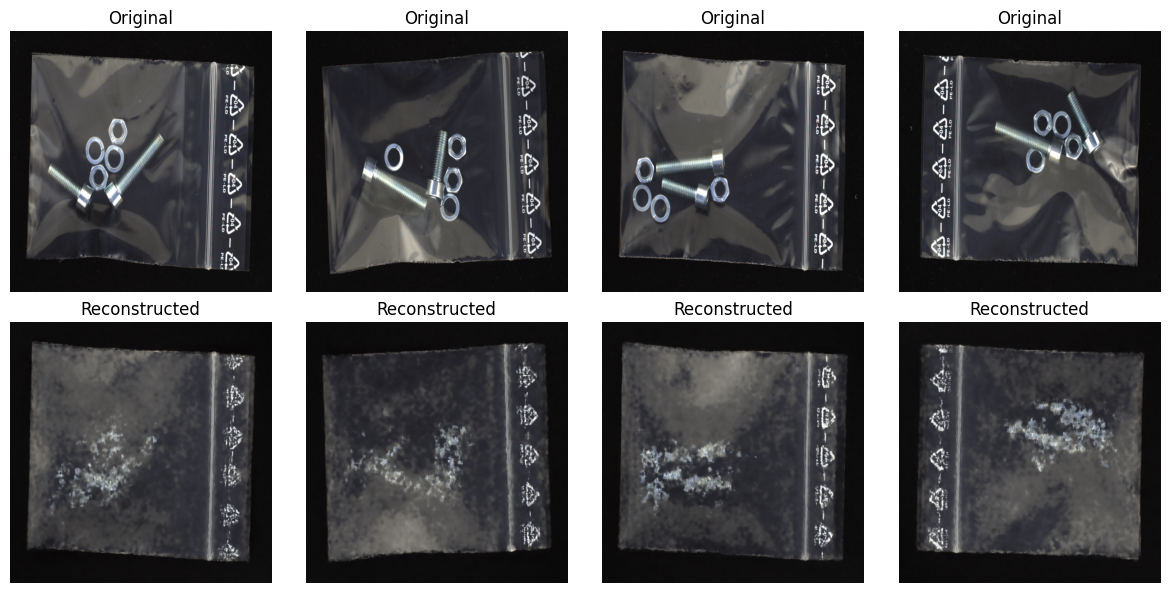

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 531/1020, Train Loss: 0.058458, Recon Loss: 0.055696, KL Loss: 2.762402, Test Loss: 0.051855, AUROC: 0.7394


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 532/1020, Train Loss: 0.057608, Recon Loss: 0.054835, KL Loss: 2.772133, Test Loss: 0.051934, AUROC: 0.7371


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 538/1020, Train Loss: 0.055639, Recon Loss: 0.052850, KL Loss: 2.788568, Test Loss: 0.052031, AUROC: 0.7239


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 539/1020, Train Loss: 0.055231, Recon Loss: 0.052444, KL Loss: 2.786972, Test Loss: 0.051577, AUROC: 0.7226


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 540/1020, Train Loss: 0.055636, Recon Loss: 0.052835, KL Loss: 2.801417, Test Loss: 0.052344, AUROC: 0.7301


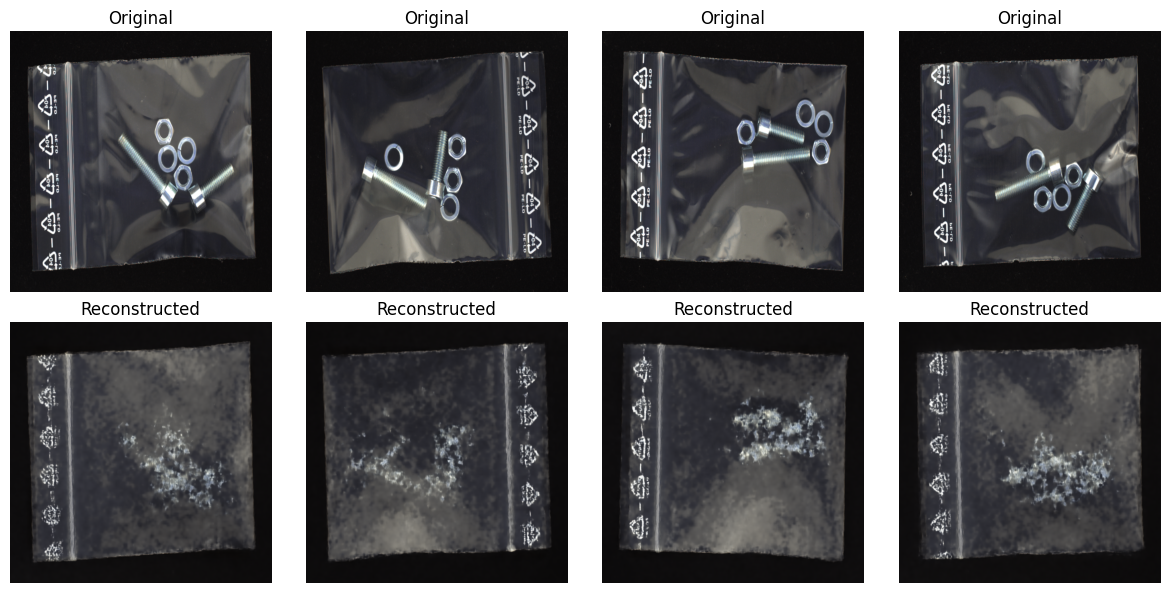

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 541/1020, Train Loss: 0.055039, Recon Loss: 0.052237, KL Loss: 2.802908, Test Loss: 0.051867, AUROC: 0.7178


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 542/1020, Train Loss: 0.054430, Recon Loss: 0.051619, KL Loss: 2.811118, Test Loss: 0.052793, AUROC: 0.7245


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


...

Epoch 548/1020, Train Loss: 0.053519, Recon Loss: 0.050708, KL Loss: 2.811199, Test Loss: 0.052341, AUROC: 0.7196


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 549/1020, Train Loss: 0.053084, Recon Loss: 0.050269, KL Loss: 2.814439, Test Loss: 0.052569, AUROC: 0.7288


Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Epoch 550/1020, Train Loss: 0.053099, Recon Loss: 0.050283, KL Loss: 2.815824, Test Loss: 0.051978, AUROC: 0.7268


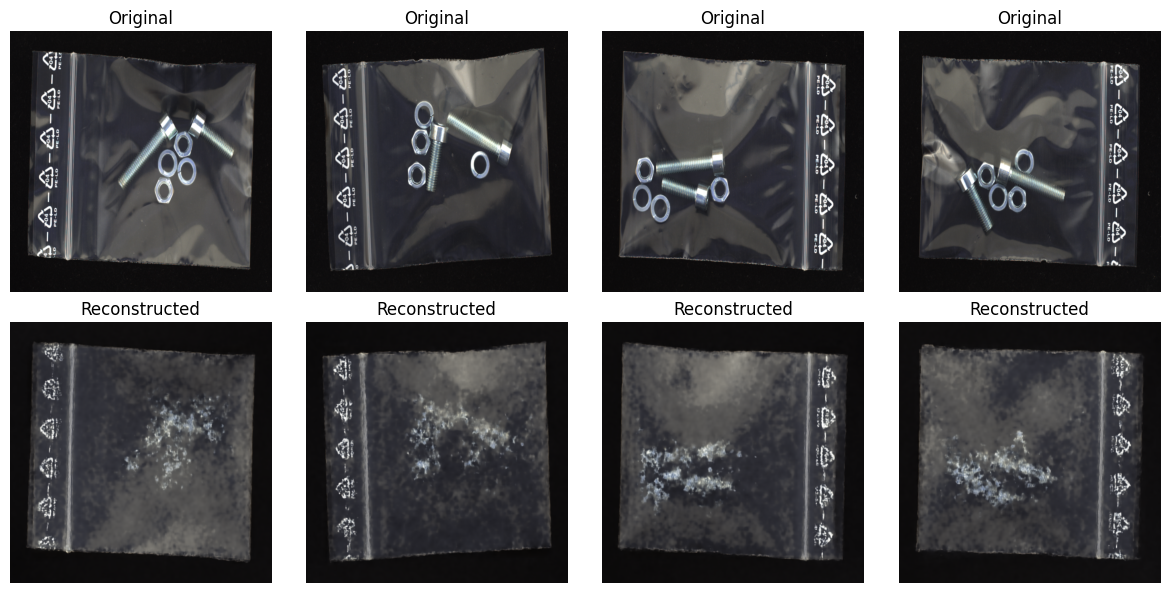

Training:   0%|          | 0/90 [00:00<?, ?it/s]/home/hafiz/my_thesis/seg_recons/venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


KeyboardInterrupt: 

In [9]:
def main():
    # Hyperparameters
    img_size = (1024, 1024)
    patch_size = 64
    in_channels = 3
    embed_dim = 128
    depth = 6
    num_heads = 8
    batch_size = 4  # Adjust based on GPU memory
    num_epochs = 500  # Number of additional epochs you want to train
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"
    
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    # Datasets and Dataloaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, Loss, Optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ViTVAE(img_size=img_size, patch_size=patch_size, in_channels=in_channels,
                   embed_dim=embed_dim, depth=depth, num_heads=num_heads).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #criterion = nn.MSELoss(reduction='none')  # Compute per-pixel loss

    # Load the saved model and optimizer states
    checkpoint_path = '/home/hafiz/my_thesis/seg_recons/VitVae2_checkpoint_epoch_520.pth'
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Load model state
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Load optimizer state
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        # Set the starting epoch to the saved epoch
        start_epoch = checkpoint['epoch'] + 1  # Continue training from the next epoch
        print(f"Resuming training from epoch {start_epoch}.")
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")
        start_epoch = 0  # If no checkpoint is found, start from epoch 0

    # Training Loop
    for epoch in range(start_epoch, start_epoch + num_epochs):
        # train_loss, train_recon_loss, train_kld_loss = train(
        #     model, train_loader, optimizer, criterion, device
        # )
        # test_loss, auroc = evaluate(model, test_loader, criterion, device)

        train_loss, train_recon_loss, train_kld_loss = train(
            model, train_loader, optimizer, device
        )
        test_loss, auroc = evaluate(model, test_loader, device)

        print(
            f"Epoch {epoch+1}/{start_epoch + num_epochs}, "
            f"Train Loss: {train_loss:.6f}, Recon Loss: {train_recon_loss:.6f}, KL Loss: {train_kld_loss:.6f}, "
            f"Test Loss: {test_loss:.6f}, AUROC: {auroc:.4f}"
        )
        if (epoch + 1) % 10 == 0:
            visualize_reconstruction(model, test_loader, device)
        if (epoch + 1) % 30 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f'VitVae2_ssim_checkpoint_epoch_{epoch+1}.pth')
            
    # Save the model after each epoch (optional)
    torch.save(model.state_dict(), f'VitVae2_ssim_epoch_{epoch+1}.pth')
    torch.save(optimizer.state_dict(), f'VitVae2_ssim_optim_epoch_{epoch+1}.pth')

if __name__ == "__main__":
    main()


In [ ]:
def main():
    # Hyperparameters
    img_size = (1024, 1024)
    patch_size = 64
    in_channels = 3
    embed_dim = 128
    depth = 6
    num_heads = 8
    batch_size = 4  # Adjust based on GPU memory
    num_epochs = 100  # Number of additional epochs you want to train
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"
    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    # Datasets and Dataloaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, Loss, Optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ViTVAE(img_size=img_size, patch_size=patch_size, in_channels=in_channels,
                   embed_dim=embed_dim, depth=depth, num_heads=num_heads).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction='none')  # Compute per-pixel loss

    # Load the saved model weights
    checkpoint_path = 'VitVae2_epoch_140.pth'  # Path to your saved .pth file
    if os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from '{checkpoint_path}'")
        model.load_state_dict(torch.load(checkpoint_path))
        print("Checkpoint loaded successfully.")
    else:
        print(f"No checkpoint found at '{checkpoint_path}'")

    # Adjust the starting epoch
    start_epoch = 140  # Since you've trained for 100 epochs already

    # Training Loop
    for epoch in range(start_epoch, start_epoch + num_epochs):
        train_loss, train_recon_loss, train_kld_loss = train(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, auroc = evaluate(model, test_loader, criterion, device)
        print(
            f"Epoch {epoch+1}/{start_epoch + num_epochs}, "
            f"Train Loss: {train_loss:.6f}, Recon Loss: {train_recon_loss:.6f}, KL Loss: {train_kld_loss:.6f}, "
            f"Test Loss: {test_loss:.6f}, AUROC: {auroc:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            visualize_reconstruction(model, test_loader, device)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, f'VitVae2_checkpoint_epoch_{epoch+1}.pth')
            
    # Save the model after each epoch (optional)
    torch.save(model.state_dict(), f'VitVae2_epoch_{epoch+1}.pth')
    torch.save(optimizer.state_dict(), f'VitVae2_optim_epoch_{epoch+1}.pth')

if __name__ == "__main__":
    main()


In [ ]:
def main():
    # Hyperparameters
    img_size = (1024, 1024)
    patch_size = 64
    in_channels = 3
    embed_dim = 128
    depth = 6
    num_heads = 8
    batch_size = 4  # Adjust based on GPU memory
    num_epochs = 100
    learning_rate = 1e-4
    ROOT_DIR = "/home/hafiz/my_thesis/seg_recons/dataset/screw_bag"

    # # Transformations
    # transform = transforms.Compose([
    #     transforms.Resize(img_size),
    #     transforms.ToTensor(),  
    #     transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    # ])

    transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    ])
    
    # Datasets and Dataloaders
    train_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='train', transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    test_dataset = MVTecLOCODataset(root_dir=ROOT_DIR, split='test', transform=transform)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model, Loss, Optimizer
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ViTVAE(img_size=img_size, patch_size=patch_size, in_channels=in_channels,
                   embed_dim=embed_dim, depth=depth, num_heads=num_heads).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss(reduction='none')  # Compute per-pixel loss

    # Training Loop
    for epoch in range(num_epochs):
        train_loss, train_recon_loss, train_kld_loss = train(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, auroc = evaluate(model, test_loader, criterion, device)
        print(
            f"Epoch {epoch+1}/{num_epochs}, "
            f"Train Loss: {train_loss:.6f}, Recon Loss: {train_recon_loss:.6f}, KL Loss: {train_kld_loss:.6f}, "
            f"Test Loss: {test_loss:.6f}, AUROC: {auroc:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            visualize_reconstruction(model, test_loader, device)
            
    # Visualize Reconstructions
    torch.save(model.state_dict(), f'VitVae2_epoch_{epoch+1}.pth')
if __name__ == "__main__":
    main()
